# 05.31 - Model Selection & Comparison Framework

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

With dozens of algorithms, how do you choose the right one? A systematic comparison framework helps.

## 2. Why Does This Matter?

No single model is best for all problems. Knowing when to use what saves time.

## 3. Prerequisites

- All previous notebooks

## 4. Learning Objectives

- Build a systematic model comparison framework
- Know when to use each algorithm
- Create a decision tree for model selection

## 5. Mental Model

Start simple (linear). Try tree-based. Try ensemble. Try complex (NN).
Compare on multiple metrics. Choose based on constraints.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time, warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. Classification Benchmark

In [2]:
X_clf, y_clf = make_classification(n_samples=2000, n_features=20, n_informative=10, random_state=42)

models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))]),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100),
    "SVM": Pipeline([("scaler", StandardScaler()), ("clf", SVC())]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for name, model in models.items():
    start = time.time()
    scores = cross_val_score(model, X_clf, y_clf, cv=cv)
    elapsed = time.time() - start
    results.append({
        "Model": name,
        "CV Accuracy": round(scores.mean(), 4),
        "Std": round(scores.std(), 4),
        "Time (s)": round(elapsed, 2)
    })

results_df = pd.DataFrame(results).sort_values("CV Accuracy", ascending=False)
print(results_df.to_string(index=False))

              Model  CV Accuracy    Std  Time (s)
                SVM       0.9290 0.0118      2.17
      Random Forest       0.9115 0.0106      8.63
  Gradient Boosting       0.9090 0.0111     18.88
                KNN       0.8970 0.0158      5.63
Logistic Regression       0.8500 0.0229      0.45
      Decision Tree       0.8140 0.0163      0.26


## 7. Visual Comparison

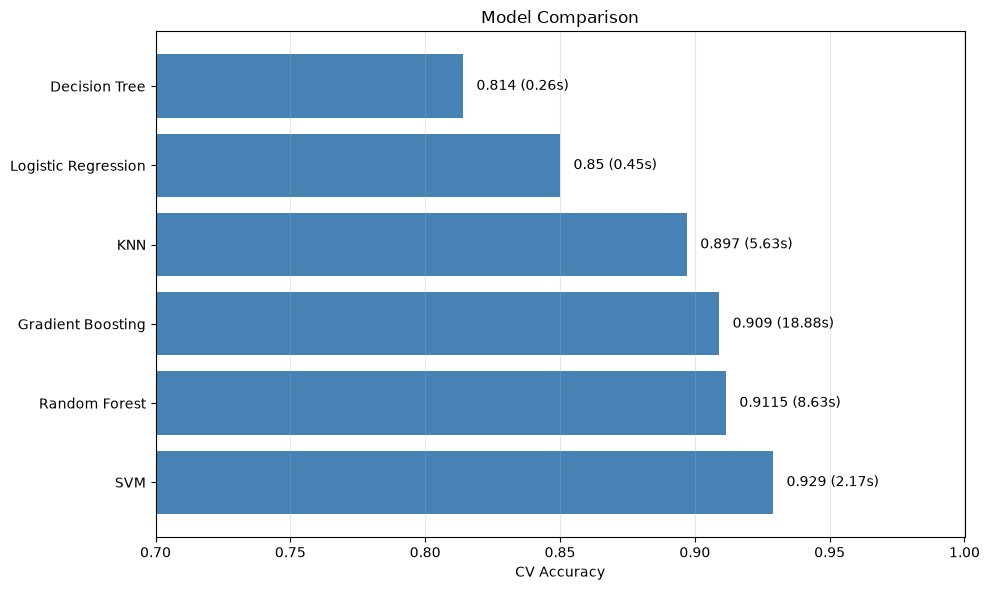

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
models_list = results_df["Model"].tolist()
accs = results_df["CV Accuracy"].tolist()
times = results_df["Time (s)"].tolist()

ax.barh(models_list, accs, color="steelblue")
ax.set_xlabel("CV Accuracy")
ax.set_title("Model Comparison")
ax.set_xlim(0.7, 1.0)
for i, (acc, t) in enumerate(zip(accs, times)):
    ax.text(acc + 0.005, i, str(acc) + " (" + str(t) + "s)", va="center")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

## 8. Decision Tree for Model Selection

In [4]:
print("MODEL SELECTION DECISION TREE:")
print("")
print("Is data linearly separable?")
print("  YES -> Logistic Regression (fast, interpretable)")
print("  NO  -> Continue")
print("")
print("Is data tabular?")
print("  YES -> Try Random Forest or Gradient Boosting")
print("  NO  -> Continue")
print("")
print("Is data image/text/sequence?")
print("  YES -> Neural Network")
print("  NO  -> Continue")
print("")
print("Small dataset (<1000)?")
print("  YES -> SVM or KNN")
print("  NO  -> Try ensemble methods")

MODEL SELECTION DECISION TREE:

Is data linearly separable?
  YES -> Logistic Regression (fast, interpretable)
  NO  -> Continue

Is data tabular?
  YES -> Try Random Forest or Gradient Boosting
  NO  -> Continue

Is data image/text/sequence?
  YES -> Neural Network
  NO  -> Continue

Small dataset (<1000)?
  YES -> SVM or KNN
  NO  -> Try ensemble methods


## 9. When to Use Each Algorithm

In [5]:
guidelines = [
    ["Logistic Regression", "Linear boundary, interpretable, baseline", "Non-linear patterns"],
    ["Decision Tree", "Non-linear, interpretable, fast", "Overfitting, unstable"],
    ["Random Forest", "Non-linear, robust, good default", "Slow inference, less interpretable"],
    ["Gradient Boosting", "Best performance on tabular", "Slow to train, many hyperparameters"],
    ["SVM", "Small-medium data, high-dimensional", "Slow on large data, kernel choice"],
    ["KNN", "Small data, no training needed", "Slow inference, curse of dimensionality"]
]
print(pd.DataFrame(guidelines, columns=["Algorithm", "Use When", "Avoid When"]).to_string(index=False))

          Algorithm                                 Use When                              Avoid When
Logistic Regression Linear boundary, interpretable, baseline                     Non-linear patterns
      Decision Tree          Non-linear, interpretable, fast                   Overfitting, unstable
      Random Forest         Non-linear, robust, good default      Slow inference, less interpretable
  Gradient Boosting              Best performance on tabular     Slow to train, many hyperparameters
                SVM      Small-medium data, high-dimensional       Slow on large data, kernel choice
                KNN           Small data, no training needed Slow inference, curse of dimensionality


## 10. Coding Exercises

### Exercise 1: Run the Benchmark
Run the comparison on a real dataset.

### Exercise 2: Speed vs Accuracy
Plot speed vs accuracy for different models.

In [6]:
# EXERCISE 1: Real dataset benchmark
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
print("Features:", data.data.shape[1], "Samples:", data.data.shape[0])

Features: 30 Samples: 569


In [7]:
# EXERCISE 2: Speed vs accuracy
print("Exercise: Plot inference time vs accuracy.")

Exercise: Plot inference time vs accuracy.


## 11. Closed-Book Recall

1. What is the best default model for tabular data?
2. When would you choose SVM over Random Forest?
3. What metric should you optimize for imbalanced data?

## 12. Teach-Back Questions

Explain model selection to a business stakeholder. How to choose based on constraints.

## 13. Summary

No single model is best. Start simple, iterate. Compare on accuracy, speed, and interpretability. Use the decision tree for guidance.

## 14. Further Experiment

1. Benchmark on a Kaggle dataset.
2. Add XGBoost and LightGBM.
3. Create an automated comparison tool.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, scikit-learn]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```